In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize


In [2]:
def wind_field_star(r_star, wind_spec):
    return np.array(wind_spec["u_star"], dtype=float)

def odes_star(tau, y, Gamma, Lambda, wind_spec):
    r = y[0:3]
    v = y[3:6]
    u = wind_field_star(r, wind_spec)

    vrel = v - u
    speed = np.linalg.norm(vrel)

    drdt = v
    dvdt = np.array([0.0, 0.0, -Gamma]) - Lambda * speed * vrel
    return np.concatenate([drdt, dvdt])


In [3]:
def hit_ground_event(tau, y):
    return y[2]

hit_ground_event.terminal = True
hit_ground_event.direction = -1


In [4]:
def initial_velocity(theta, phi):
    return np.array([
        np.cos(theta) * np.cos(phi),
        np.cos(theta) * np.sin(phi),
        np.sin(theta)
    ])


In [5]:
def simulate(theta, phi, Gamma, Lambda, wind_spec,
             z0_star=0.0, tau_max=30.0):

    y0 = np.zeros(6)
    y0[0:3] = [0.0, 0.0, z0_star]
    y0[3:6] = initial_velocity(theta, phi)

    sol = solve_ivp(
        lambda t, y: odes_star(t, y, Gamma, Lambda, wind_spec),
        (0.0, tau_max),
        y0,
        events=hit_ground_event,
        rtol=1e-4,
        atol=1e-6,
        max_step=0.05
    )

    if sol.status != 1:
        return None, None

    xL, yL = sol.y[0, -1], sol.y[1, -1]
    rL = np.hypot(xL, yL)
    psiL = np.arctan2(yL, xL)

    return sol, {"xL": xL, "yL": yL, "rL": rL, "psiL": psiL}


In [6]:
wind_opt = [
    {"u_star": (0.0, 0.0, 0.0)},
    {"u_star": (0.15, 0.0, 0.0)},
    {"u_star": (0.15, 0.15, 0.0)},
]


In [7]:
def make_full_winds():
    winds = []
    speeds = [0.0, 0.1, 0.2, 0.3]
    dirs = [(1,0),(0,1),(-1,0),(0,-1),(1,1),(-1,1)]
    for U in speeds:
        for dx, dy in dirs:
            d = np.hypot(dx, dy)
            winds.append({"u_star": (U*dx/d, U*dy/d, 0.0)})
    return winds

wind_full = make_full_winds()


In [8]:
def sector_bounds(k, n=5):
    dpsi = 2*np.pi/n
    return k*dpsi, (k+1)*dpsi


In [9]:
def objective(x, Gamma, Lambda, winds, target, sector=0):
    theta, phi = x
    if not (np.deg2rad(35) <= theta <= np.deg2rad(75)):
        return 100.0

    psi_min, psi_max = sector_bounds(sector)
    cost = 0.0

    for w in winds:
        sol, land = simulate(theta, phi, Gamma, Lambda, w)
        if land is None:
            cost += 10
            continue

        rL, psiL = land["rL"], land["psiL"]
        err = (land["xL"] - target[0])**2 + (land["yL"] - target[1])**2

        if rL > 1.0:
            err += 10*(rL-1)**2
        if not (psi_min <= (psiL%(2*np.pi)) <= psi_max):
            err += 5

        cost += err

    return cost / len(winds)


In [10]:
Gamma  = 0.12
Lambda = 0.05

sector = 0
psi_min, psi_max = sector_bounds(sector)
psi_mid = 0.5*(psi_min + psi_max)

target = (0.8*np.cos(psi_mid), 0.8*np.sin(psi_mid))

thetas = np.deg2rad(np.linspace(40, 70, 16))
phis   = np.linspace(psi_min, psi_max, 16)

best_val = np.inf
best_params = None

for th in thetas:
    for ph in phis:
        val = objective([th, ph], Gamma, Lambda, wind_opt, target, sector)
        if val < best_val:
            best_val = val
            best_params = (th, ph)

theta_opt, phi_opt = best_params
np.rad2deg(theta_opt), np.rad2deg(phi_opt)


(np.float64(70.0), np.float64(67.19999999999999))

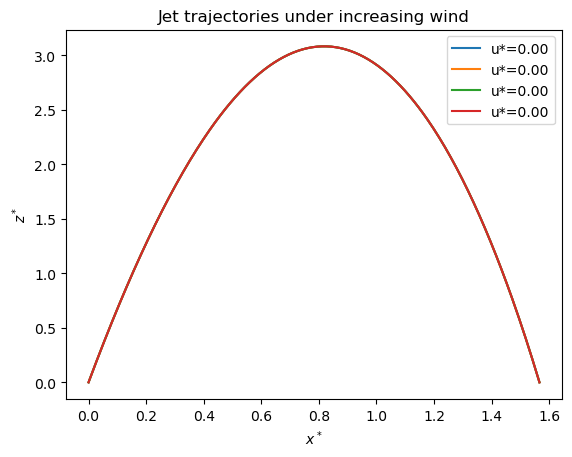

In [11]:
plt.figure()
for w in wind_full[:4]:
    sol, _ = simulate(theta_opt, phi_opt, Gamma, Lambda, w)
    plt.plot(sol.y[0], sol.y[2], label=f"u*={np.hypot(*w['u_star'][:2]):.2f}")
plt.xlabel(r"$x^*$")
plt.ylabel(r"$z^*$")
plt.title("Jet trajectories under increasing wind")
plt.legend()
plt.show()


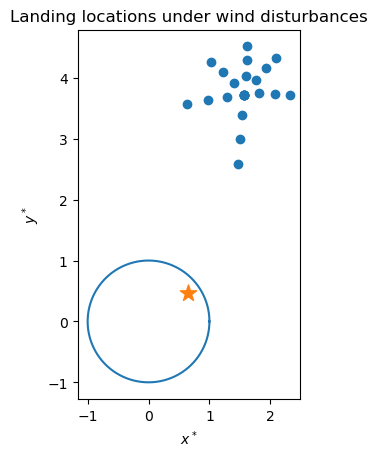

In [12]:
xs, ys = [], []

for w in wind_full:
    _, land = simulate(theta_opt, phi_opt, Gamma, Lambda, w)
    if land:
        xs.append(land["xL"])
        ys.append(land["yL"])

theta = np.linspace(0, 2*np.pi, 400)
plt.figure()
plt.plot(np.cos(theta), np.sin(theta))
plt.scatter(xs, ys)
plt.scatter(*target, marker="*", s=150)
plt.gca().set_aspect("equal")
plt.xlabel(r"$x^*$")
plt.ylabel(r"$y^*$")
plt.title("Landing locations under wind disturbances")
plt.show()


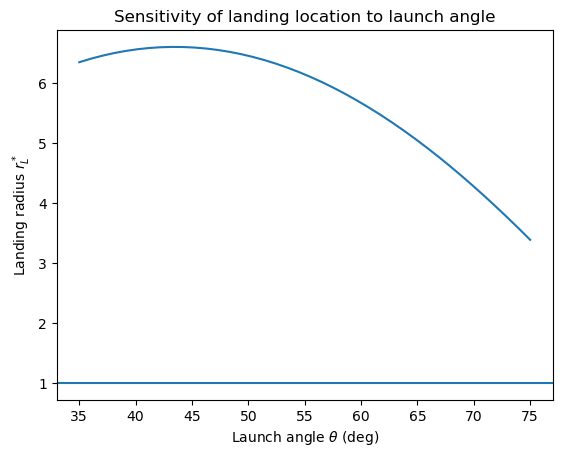

In [13]:
angles = np.deg2rad(np.linspace(35, 75, 40))
rvals = []

wind_fixed = {"u_star": (0.2, 0.0, 0.0)}

for th in angles:
    _, land = simulate(th, phi_opt, Gamma, Lambda, wind_fixed)
    rvals.append(np.nan if land is None else land["rL"])

plt.figure()
plt.plot(np.rad2deg(angles), rvals)
plt.axhline(1.0)
plt.xlabel(r"Launch angle $\theta$ (deg)")
plt.ylabel(r"Landing radius $r_L^*$")
plt.title("Sensitivity of landing location to launch angle")
plt.show()


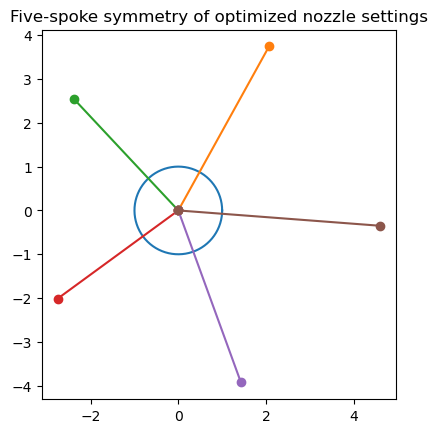

In [14]:
plt.figure()
plt.plot(np.cos(theta), np.sin(theta))

for i in range(5):
    phi_i = phi_opt + i*(2*np.pi/5)
    _, land = simulate(theta_opt, phi_i, Gamma, Lambda, wind_fixed)
    if land:
        plt.plot([0, land["xL"]], [0, land["yL"]], marker="o")

plt.gca().set_aspect("equal")
plt.title("Five-spoke symmetry of optimized nozzle settings")
plt.show()
